In [1]:
from scripts.data_prep import *
import matplotlib.pyplot as plt

In [2]:
df = load_data()

c:\Users\shyam\Dp Lrn\Options\AAPL Options\scripts\data_prep.py:169: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=[callput])


no of cols =20


In [3]:
data = df[(df.TradeDate==20100218)&(df.CallPut=='c')]
data[(data.AdjExpiry==20100319)&(data.Volume>0)&(data.Delta<.6)&(data.Delta>.04)][['TradeDate','AdjExpiry','AdjSpot','AdjStrike','px','Delta','ImpliedVolatility','Volume']].sort_values(by = 'AdjStrike')

,TradeDate,AdjExpiry,AdjSpot,AdjStrike,px,Delta,ImpliedVolatility,Volume
424,20100218,20100319,7.2475,7.142857,0.291071,0.586800,0.290319,6332.0
425,20100218,20100319,7.2475,7.500000,0.123214,0.343279,0.274313,8923.0
426,20100218,20100319,7.2475,7.857143,0.042679,0.153512,0.270239,6106.0
427,20100218,20100319,7.2475,8.214286,0.014107,0.059527,0.277886,1383.0


In [4]:
def gen_vol_surface(data,callput,tradedate,interpolator = 'linear',test = True):
    data = extract_clean_data(data,callput,tradedate,test=test)
    sufrace_genrator = GenSurface(data,interpolator=interpolator)
    sufrace_genrator.update_surface()
    sufrace_genrator.surface.head()
    fwd_mnyness = sufrace_genrator.fwd_moneyness()
    x,y = sufrace_genrator.known_data()
    sufrace_genrator.gen_spline(s=.05)
    IV = sufrace_genrator.get_known_iv_surface()
    y_new = np.linspace(sufrace_genrator.known_y.min(), sufrace_genrator.known_y.max(), 100)
    idx  =np.nanargmin(IV)
    r, c = np.unravel_index(idx, [100,100])
    print(f'r:{r},c:{c}')
    return sufrace_genrator


In [5]:
sg_linear = gen_vol_surface(data,'c',20100218,)

c options traded available on 20100218:220
c options traded available on 20100218 after vertical arbitrage removed:217
c options traded available on 20100218 after calendar arbitrage removed:212
c options traded available on 20100218 after removing iv<.01 and iv>5:204
r:0,c:21


In [6]:
sg_linear.abs_error()

Mean abs error: 2.7078610356711136e-18
Max abs error : 5.551115123125783e-17


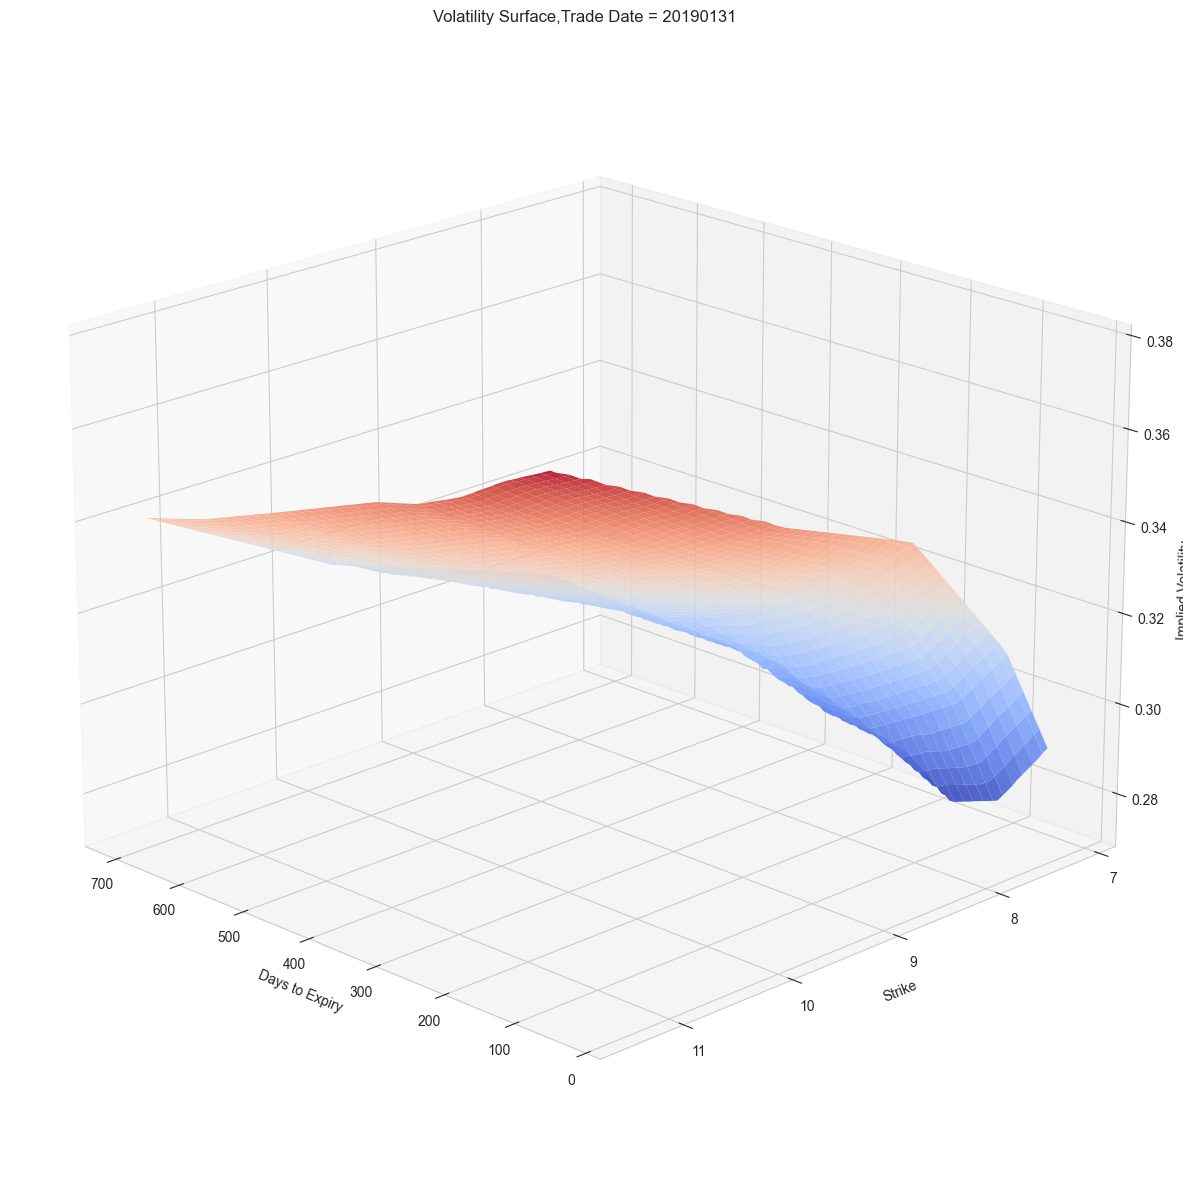

In [7]:
sg_linear.plot_surface(elev=20,azim=135)

In [8]:
sg_bicubic= gen_vol_surface(data,'c',20100218,interpolator='bicubic')

c options traded available on 20100218:220
c options traded available on 20100218 after vertical arbitrage removed:217
c options traded available on 20100218 after calendar arbitrage removed:212
c options traded available on 20100218 after removing iv<.01 and iv>5:204
r:0,c:21


In [9]:
sg_bicubic.abs_error()

Mean abs error: 0.000865054837539717
Max abs error : 0.00483084287521679


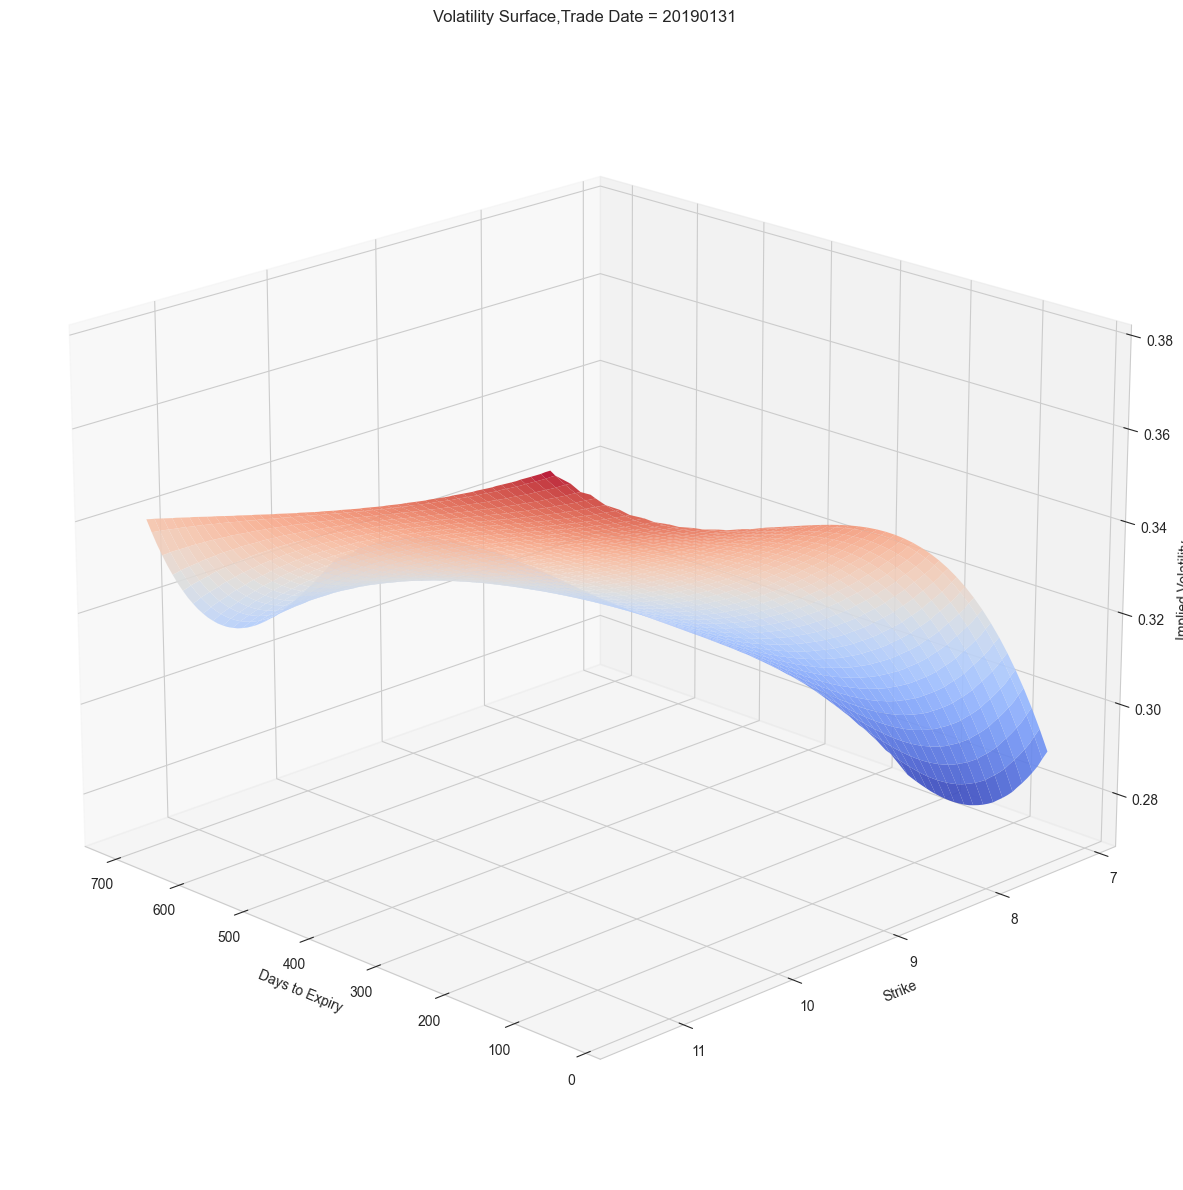

In [10]:
sg_bicubic.plot_surface(elev=20,azim=135)

In [11]:
data.AdjExpiry.unique()

array([20100219, 20100319, 20100416, 20100521, 20100716, 20100820,
       20110121, 20110218, 20120120])

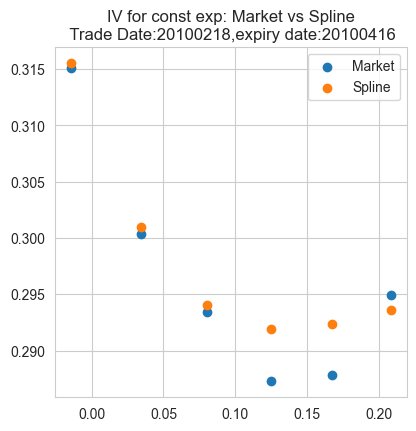

In [12]:
fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(2,2, 1)
sg_bicubic.scatter_plot_iv_exp(ax,20100416)

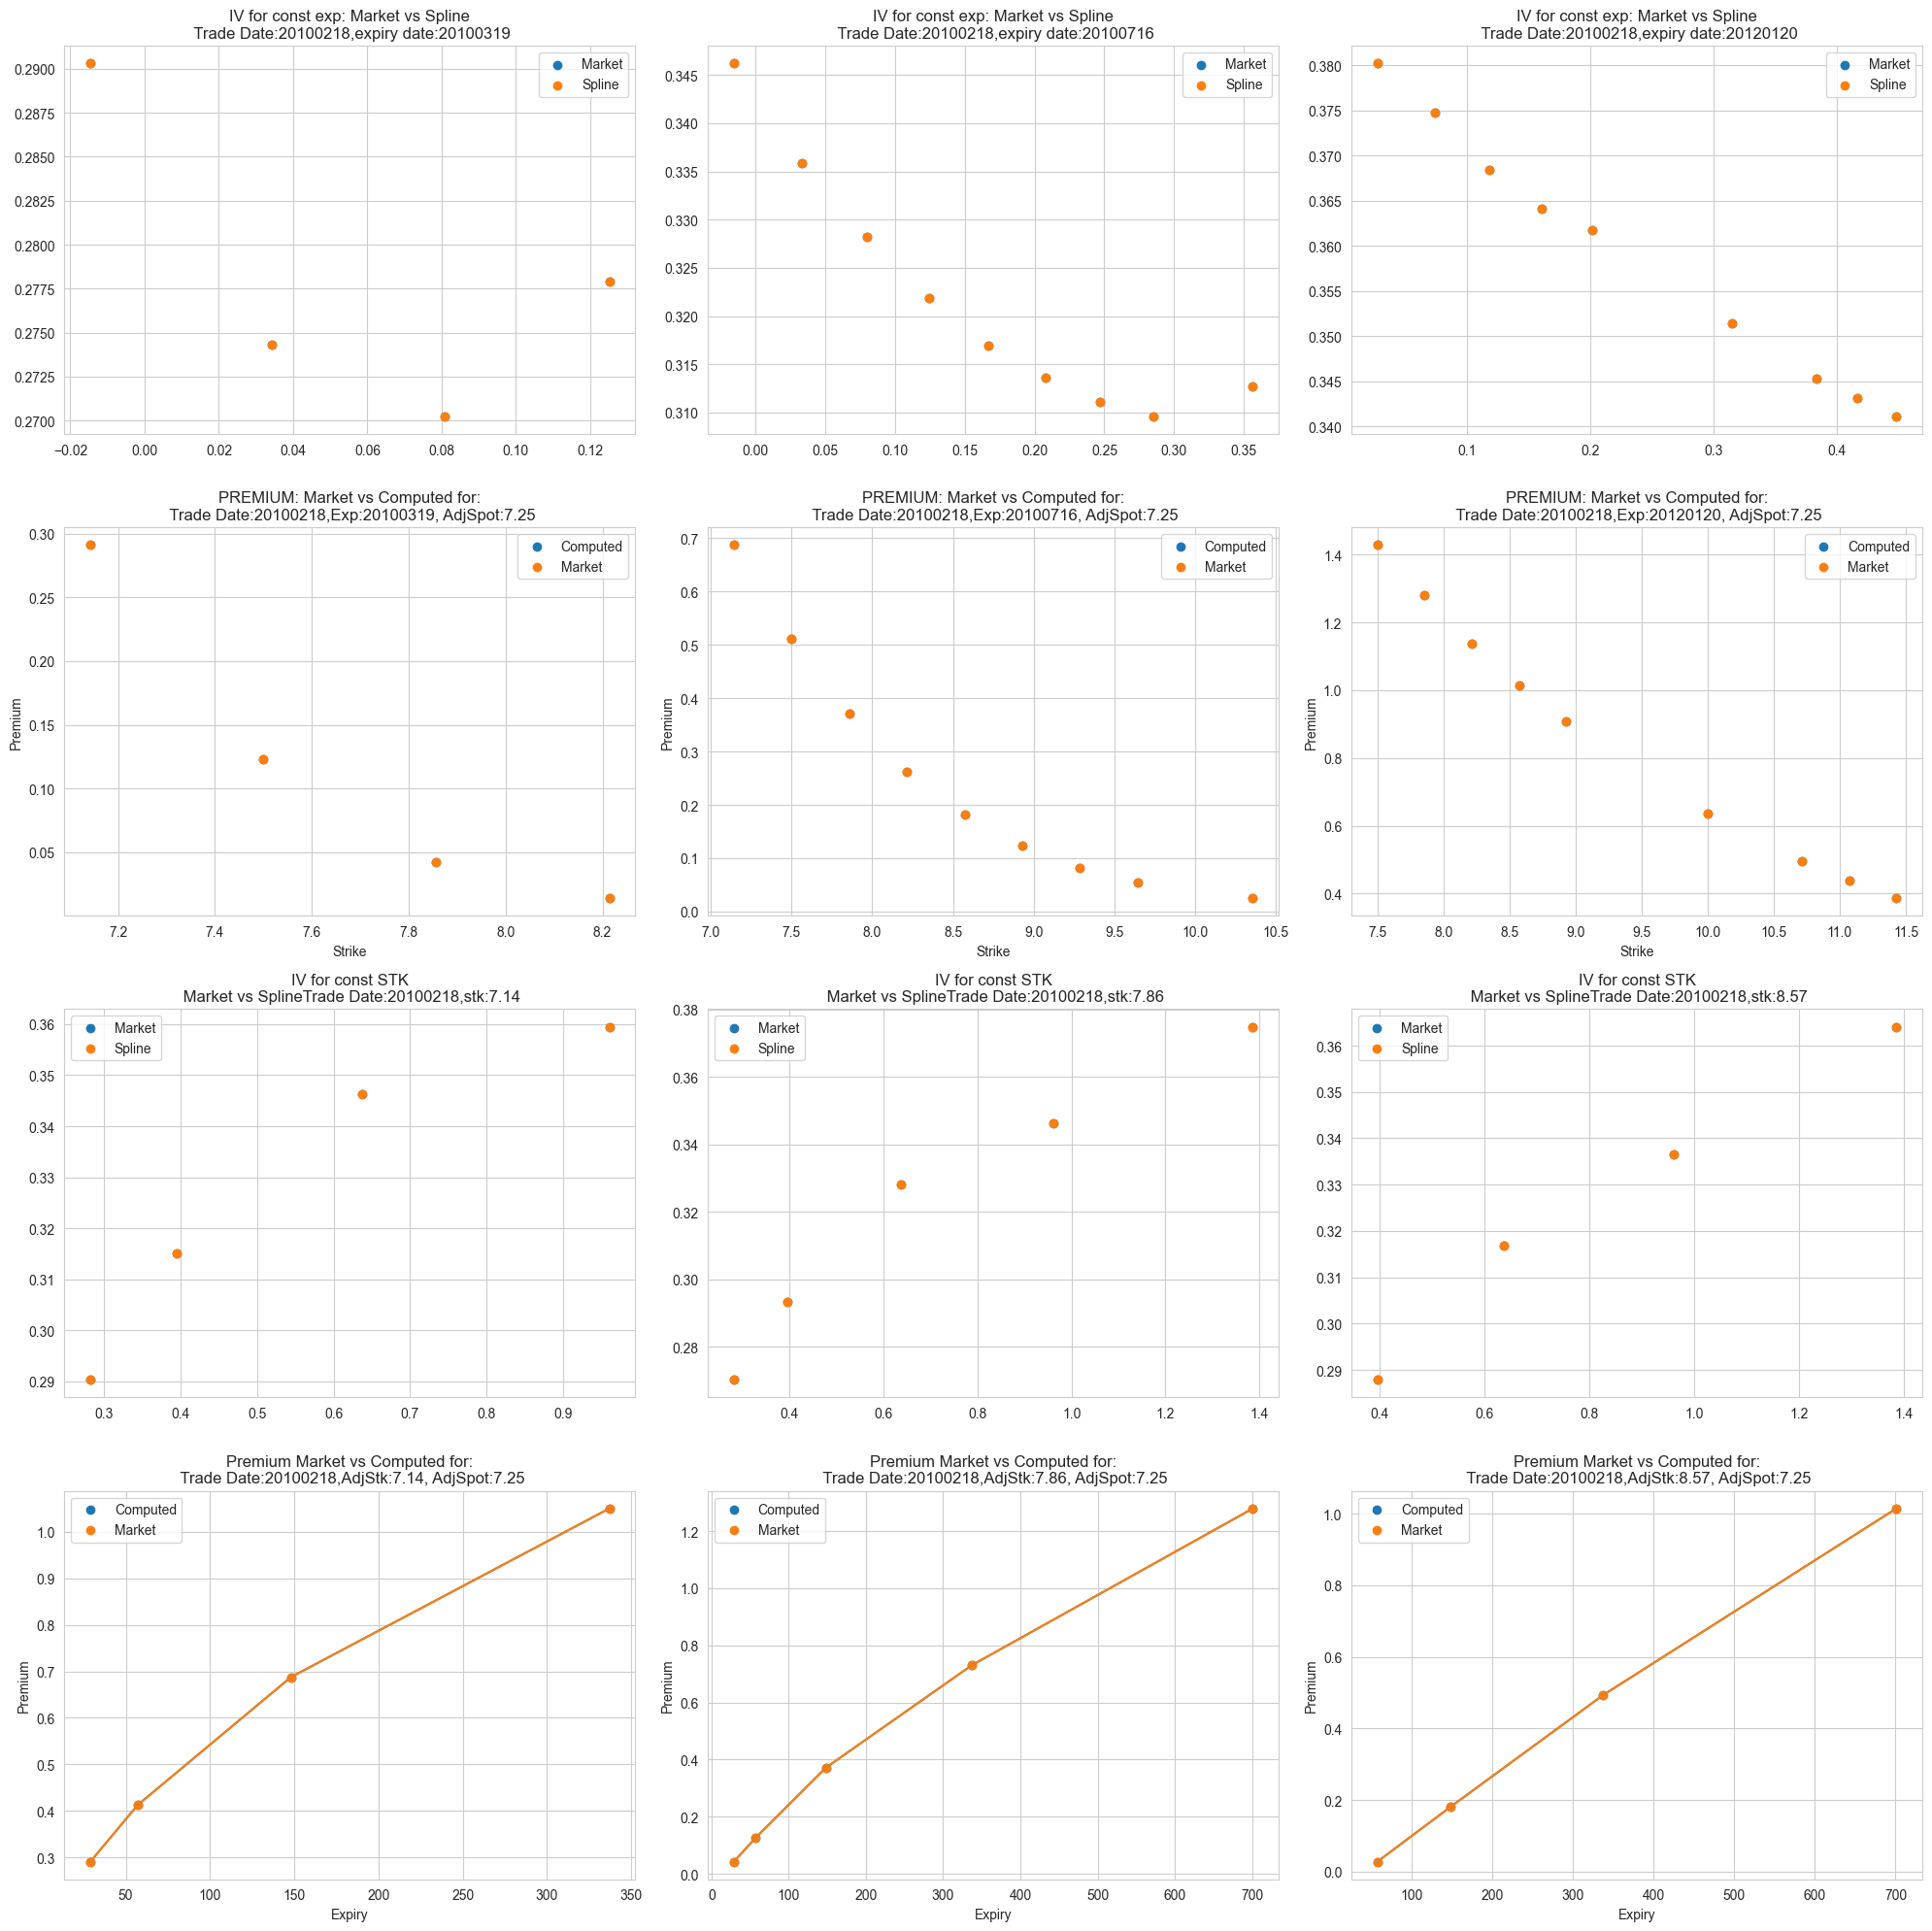

In [13]:
sg_linear.plot_simulation_results()

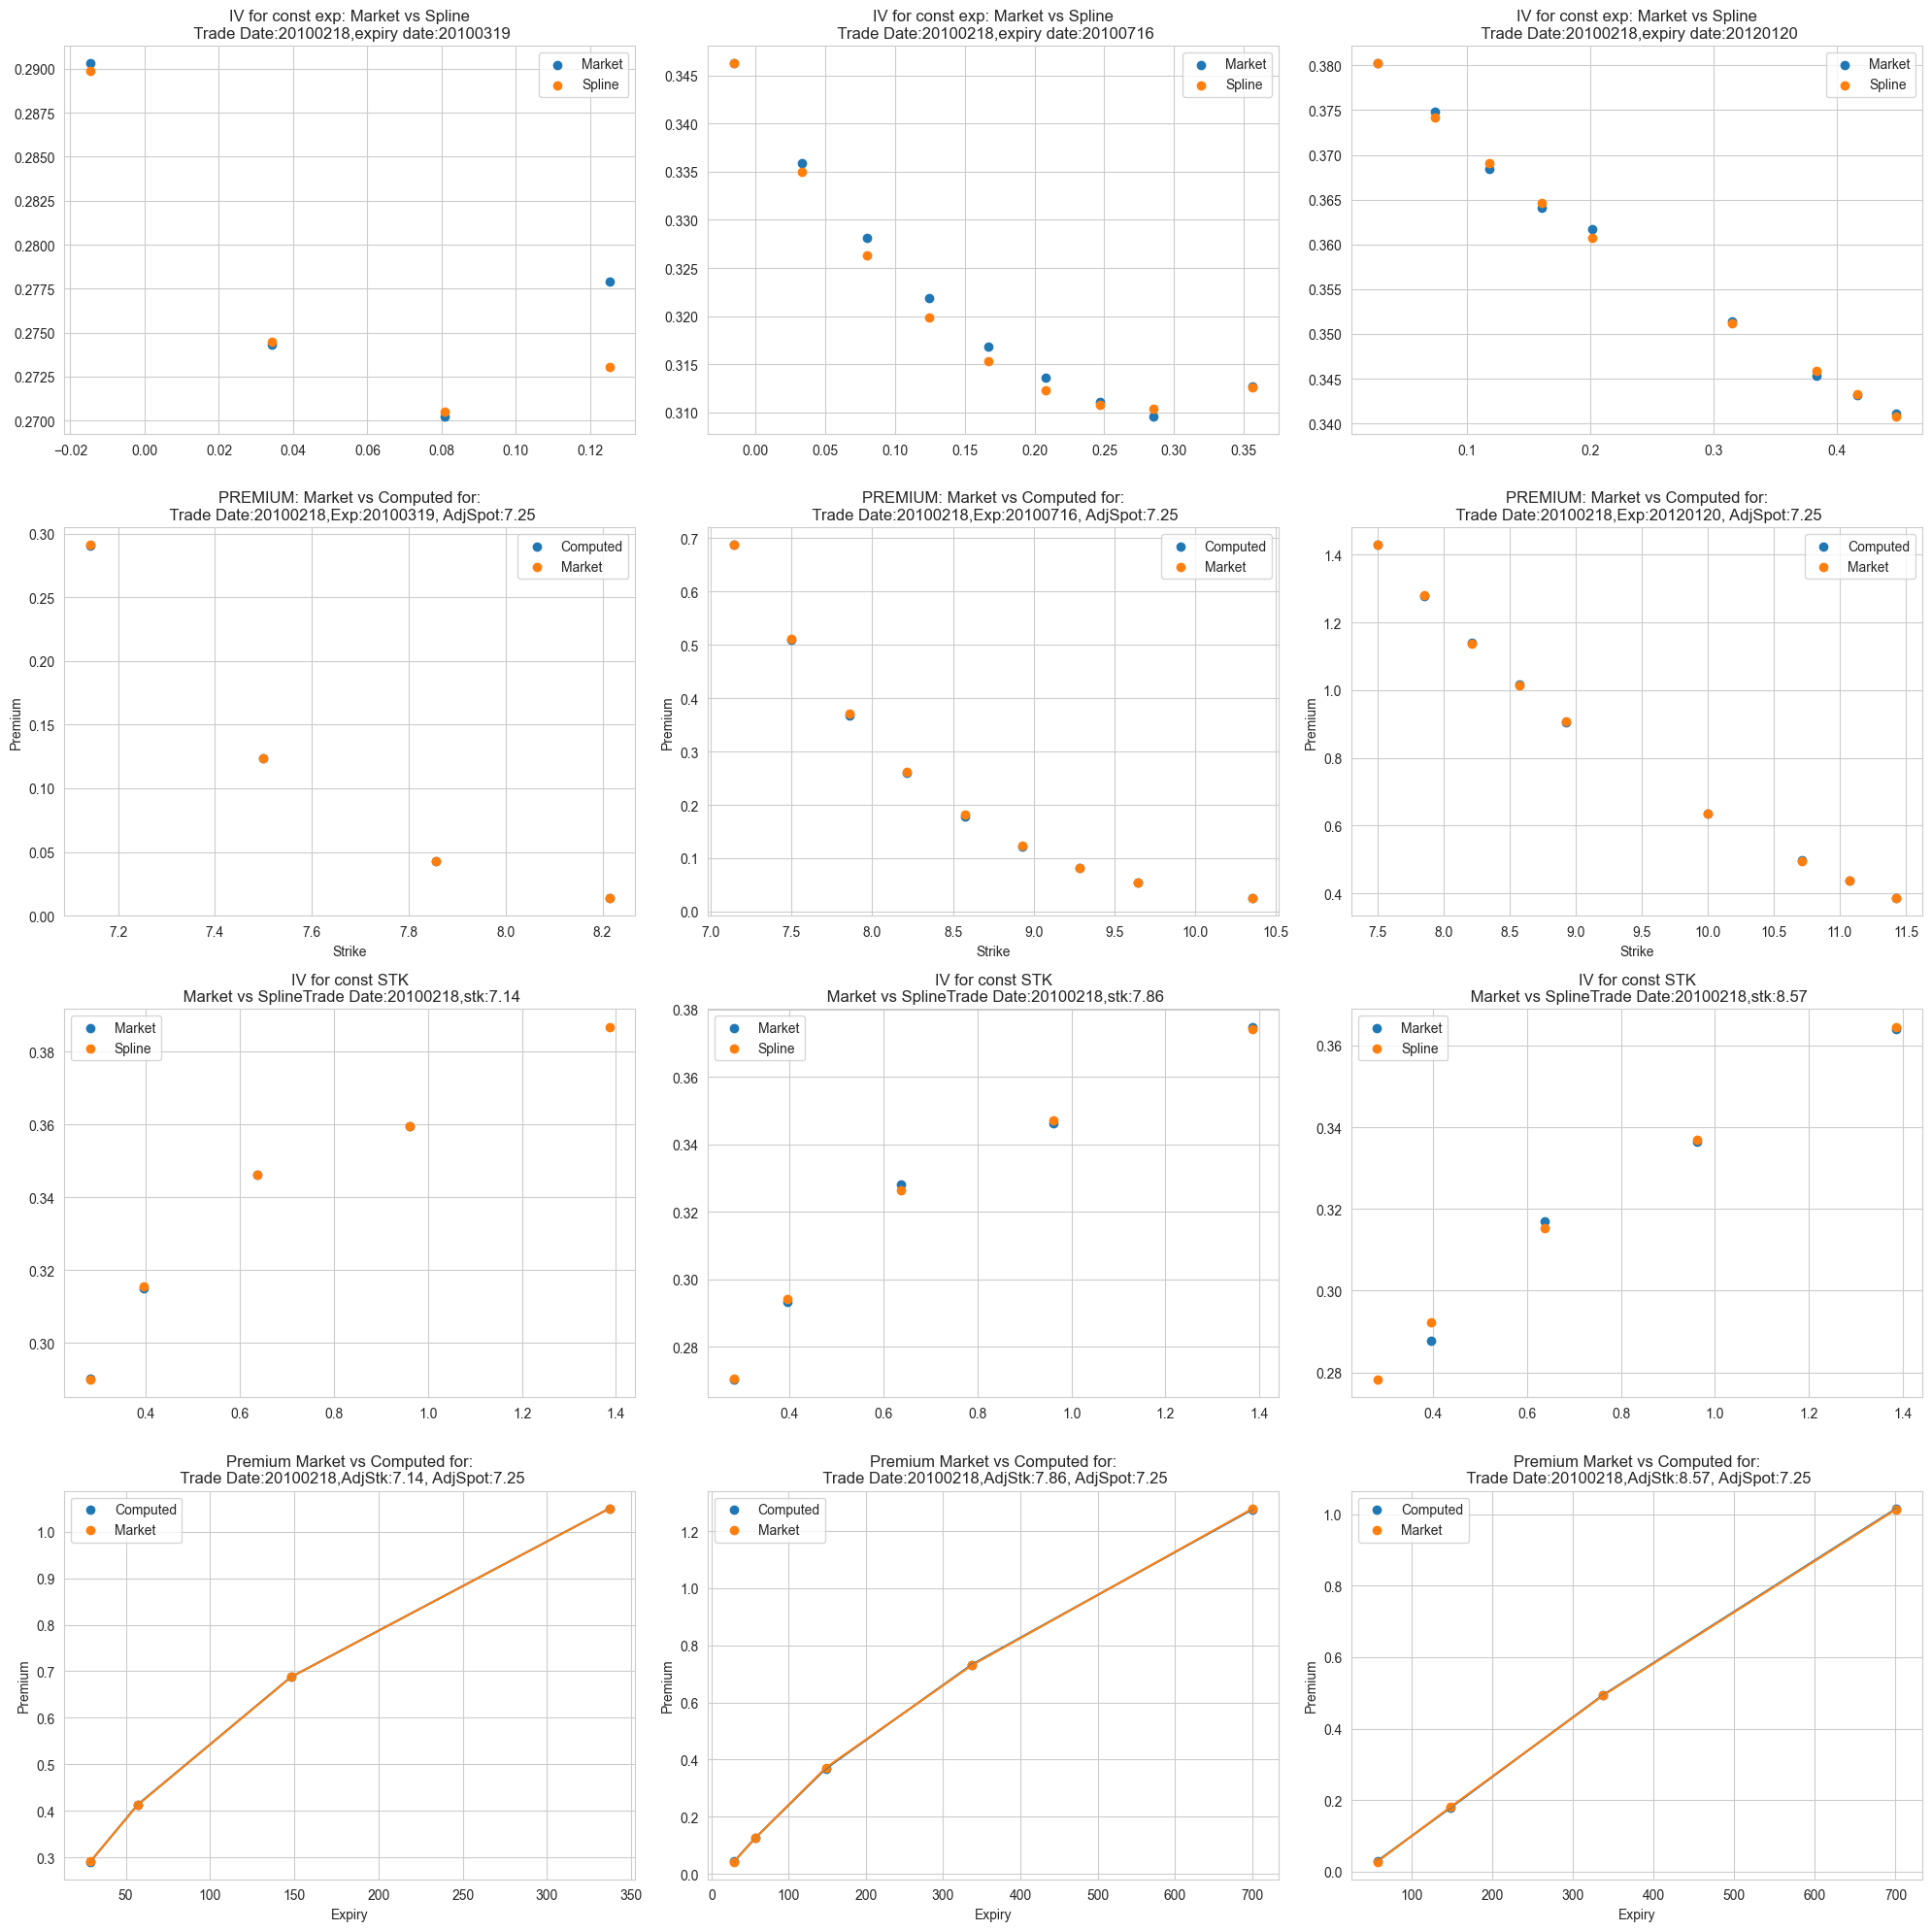

In [14]:
sg_bicubic.plot_simulation_results()